In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set(color_codes=True)

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
print(df.shape)
df.head()

(14606, 63)


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [4]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [5]:
# Train / Test Split : 75% training and 25% testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


In [6]:
# Initialise the Random Forest model
model = RandomForestClassifier(
    n_estimators=1000, 
    class_weight='balanced', 
    max_depth=10, 
    random_state=42 
)

# Train the model on the training set
# The model learns patterns that distinguish churned from retained customers
model.fit(X_train, y_train)

print('Model training complete!')
print(f'Number of trees in forest: {model.n_estimators}')
print(f'Number of features used:   {model.n_features_in_}')

Model training complete!
Number of trees in forest: 1000
Number of features used:   61


In [7]:
# Hard predictions: 0 (stays) or 1 (churns)
y_pred = model.predict(X_test)

# Probability scores: how confident is the model?
# [:, 1] = probability of churn (class 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Prediction distribution:')
print(f'  Predicted to Stay:  {(y_pred == 0).sum():,}')
print(f'  Predicted to Churn: {(y_pred == 1).sum():,}')
print(f'\nPredicted churn rate: {y_pred.mean()*100:.1f}%')
print(f'Actual churn rate:    {y_test.mean()*100:.1f}%')

Prediction distribution:
  Predicted to Stay:  3,215
  Predicted to Churn: 437

Predicted churn rate: 12.0%
Actual churn rate:    10.0%


In [8]:
# --- Core Metrics ---
accuracy  = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall    = metrics.recall_score(y_test, y_pred)
f1        = metrics.f1_score(y_test, y_pred)
auc_roc   = metrics.roc_auc_score(y_test, y_pred_proba)

print('    \nMODEL PERFORMANCE SUMMARY')
print(f'  Accuracy:  {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  Precision: {precision:.4f}  ({precision*100:.1f}%)')
print(f'  Recall:    {recall:.4f}  ({recall*100:.1f}%)')
print(f'  F1 Score:  {f1:.4f}')
print(f'  AUC-ROC:   {auc_roc:.4f}')

    
MODEL PERFORMANCE SUMMARY
  Accuracy:  0.8327  (83.3%)
  Precision: 0.2197  (22.0%)
  Recall:    0.2623  (26.2%)
  F1 Score:  0.2391
  AUC-ROC:   0.6483


In [9]:
# --- Full Classification Report ---
# Shows precision, recall and F1 for BOTH classes (stayed & churned)
print('Full Classification Report:')
print(metrics.classification_report(
    y_test, y_pred,
    target_names=['Stayed (0)', 'Churned (1)']
))

Full Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.92      0.90      0.91      3286
 Churned (1)       0.22      0.26      0.24       366

    accuracy                           0.83      3652
   macro avg       0.57      0.58      0.57      3652
weighted avg       0.85      0.83      0.84      3652



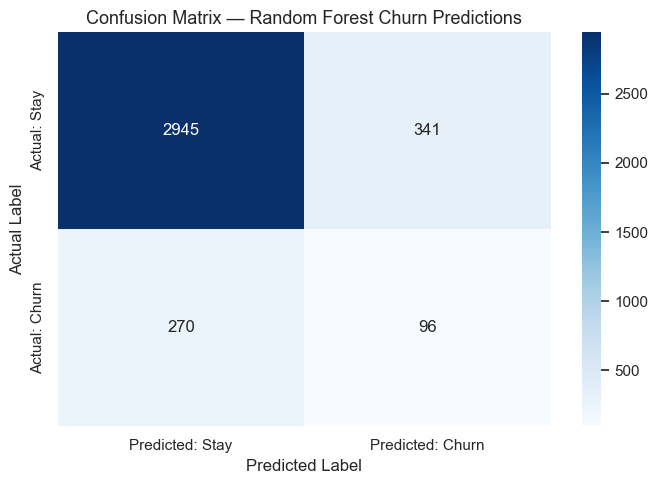

True Negatives  (Stayed, predicted Stay):   2,945
False Positives (Stayed, predicted Churn):  341  ← unnecessary discounts
False Negatives (Churned, predicted Stay):  270  ← churners we missed ❌
True Positives  (Churned, predicted Churn): 96  ← churners we caught ✅


In [10]:
# Generate confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Stay', 'Predicted: Churn'],
    yticklabels=['Actual: Stay', 'Actual: Churn'],
    ax=ax
)

ax.set_title('Confusion Matrix — Random Forest Churn Predictions', fontsize=13)
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Stayed, predicted Stay):   {tn:,}')
print(f'False Positives (Stayed, predicted Churn):  {fp:,}  ← unnecessary discounts')
print(f'False Negatives (Churned, predicted Stay):  {fn:,}  ← churners we missed ❌')
print(f'True Positives  (Churned, predicted Churn): {tp:,}  ← churners we caught ✅')

In [11]:
# Extract feature importances from the trained model
feature_importances = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 most important features:')
print(feature_importances.head(15).to_string(index=False))

Top 15 most important features:
                        feature  importance
             margin_net_pow_ele    0.069680
           margin_gross_pow_ele    0.068436
                       cons_12m    0.050450
                   months_activ    0.042733
        forecast_meter_rent_12m    0.039984
                cons_last_month    0.037827
                     net_margin    0.035472
              forecast_cons_12m    0.033404
              months_modif_prod    0.032335
    off_peak_peak_var_mean_diff    0.028336
                        pow_max    0.027736
off_peak_mid_peak_var_mean_diff    0.026375
offpeak_diff_dec_january_energy    0.025716
        var_year_price_off_peak    0.023531
                       imp_cons    0.023351


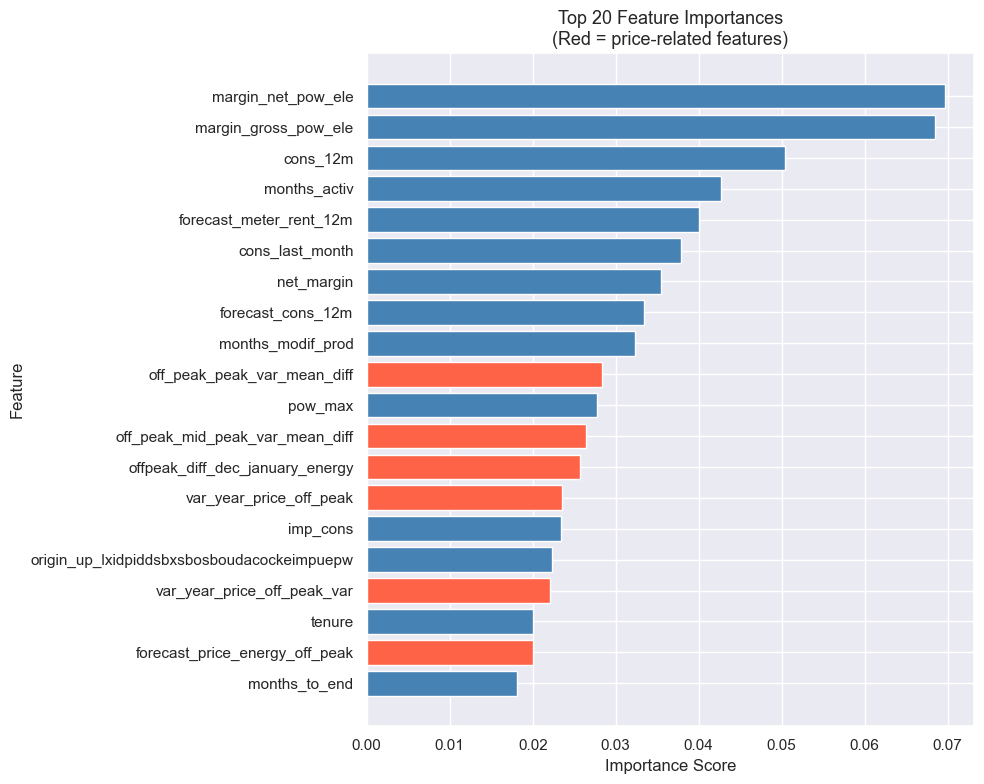

In [12]:
# Plot top 20 features
top_n = 20
top_features = feature_importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['tomato' if 'price' in f or 'offpeak' in f or 'peak' in f
          else 'steelblue'
          for f in top_features['feature']]

ax.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1],
    color=colors[::-1],
    edgecolor='white'
)

ax.set_title(f'Top {top_n} Feature Importances\n(Red = price-related features)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

 Price vs Non-Price Feature Importance
Price-related features:     0.3891 (38.9%)
Non-price features:         0.6109 (61.1%)
Total:                      1.0000


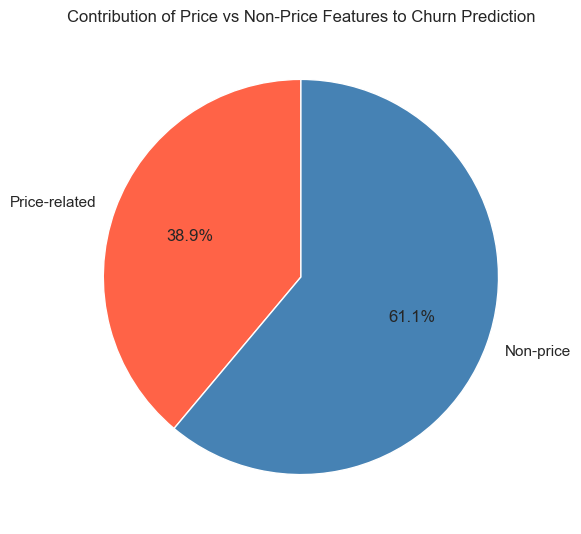

In [13]:
#how much do price features contribute overall?
price_keywords = ['price', 'offpeak', 'peak', 'diff', 'var_6m']

price_importance = feature_importances[
    feature_importances['feature'].str.contains('|'.join(price_keywords))
]['importance'].sum()

total_importance = feature_importances['importance'].sum()
non_price_importance = total_importance - price_importance

print(' Price vs Non-Price Feature Importance')
print(f'Price-related features:     {price_importance:.4f} ({price_importance*100:.1f}%)')
print(f'Non-price features:         {non_price_importance:.4f} ({non_price_importance*100:.1f}%)')
print(f'Total:                      {total_importance:.4f}')

# Simple pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [price_importance, non_price_importance],
    labels=['Price-related', 'Non-price'],
    colors=['tomato', 'steelblue'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Contribution of Price vs Non-Price Features to Churn Prediction')
plt.tight_layout()
plt.show()